### Notebook to create and analyze mock spectra that mimick the SDSS DR16 quasar spectra
### Load in packages

In [1]:
import LineLocking_FinalVersion as LineLocking
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as ticker
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from tqdm.notebook import tqdm
import cmasher as cm
from scipy.optimize import fsolve
from astropy.stats import sigma_clip
from scipy.stats import skew, kurtosis
from tabulate import tabulate

### Set user paths to spectra and read in the trough catalog
---------------------------------------------------------------------------------------
------------------------------------------Existing Save Files-------------------------------------------------------

Final: Use standard trough cuts (70609 troughs: Rejected 48032 troughs, 22577 remaining)

Final_Width1: Use standard trough cuts with 1100<w<1350 (7367 troughs: Rejected 1680 troughs, 5687 remaining)

Final_Width2: Use standard trough cuts with 1350<w<1750 (7367 troughs: Rejected 1045 troughs, 5844 remaining)

Final_Width3: Use standard trough cuts with 1750<w<2600 (6570 troughs: Rejected 959 troughs, 5611 remaining)

Final_Width4: Use standard trough cuts with 2600<w (6123 troughs: Rejected 688 troughs, 5435 remaining)

Final_SNR1: Use standard trough cuts with 2<SNR<4.2 (22510 troughs: Rejected 16956 troughs, 5554 remaining)

Final_SNR2: Use standard trough cuts with 4.2<SNR<6 (17904 troughs: Rejected 12147 troughs, 5757 remaining)

Final_SNR3: Use standard trough cuts with 6<SNR<8.6 (12962 troughs: Rejected 10013 troughs, 5541 remaining)

Final_SNR4: Use standard trough cuts with 8.6<SNR (17233 troughs: Rejected 8916 troughs, 5725 remaining) 

Final_Vel1: Use standard trough cuts with 0<POSMIN<2000 (14033 troughs: Rejected 11235 troughs, 3651 remaining)

Final_Vel2: Use standard trough cuts with 2000<POSMIN<3300 (17651 troughs: Rejected 5218 troughs, 3837 remaining)

Final_Vel3: Use standard trough cuts with 3300<POSMIN<5100 (8886 troughs: Rejected 5107 troughs, 3779 remaining)

Final_Vel4: Use standard trough cuts with 5100<POSMIN<7900 (10031 troughs: Rejected 6327 troughs, 3704 remaining)

Final_Vel5: Use standard trough cuts with 7900<POSMIN<12200 (10870 troughs: Rejected 7198 troughs, 3672 remaining)

Final_Vel6: Use standard trough cuts with 12200<POSMIN (16881 troughs: Rejected 12947 troughs, 3934 remaining)

Final_N: Use standard trough cuts (81388 troughs: Rejected 52056 troughs, 29332 remaining)

Final_N_Width1: Use standard trough cuts with 1100<w<1350 (8272 troughs: Rejected 1376 troughs, 6896 remaining)

Final_N_Width2: Use standard trough cuts with 1350<w<1750 (8003 troughs: Rejected 713 troughs, 7290 remaining)

Final_N_Width3: Use standard trough cuts with 1750<w<2600 (7736 troughs: Rejected 651 troughs. 7085 remaining.)

Final_N_Width4: Use standard trough cuts with 2600<w (8827 troughs: Rejected 766 troughs, 8061 remaining)

Final_N_Vel1: Use standard trough cuts with 0<POSMIN<2100 (14033 troughs: Rejected 11235 troughs, 3651 remaining)

Final_N_Vel2: Use standard trough cuts with 2100<POSMIN<3400 (17651 troughs: Rejected 5218 troughs, 3837 remaining)

Final_N_Vel3: Use standard trough cuts with 3400<POSMIN<5300 (8886 troughs: Rejected 6139 troughs. 4773 remaining.)

Final_N_Vel4: Use standard trough cuts with 5300<POSMIN<8500 (10031 troughs: Rejected 6327 troughs, 3704 remaining)

Final_N_Vel5: Use standard trough cuts with 8500<POSMIN<13200 (10870 troughs: Rejected 7198 troughs, 3672 remaining)

Final_N_Vel6: Use standard trough cuts with 13200<POSMIN (16881 troughs: Rejected 12947 troughs, 3934 remaining)


---------------------------------------------------------------------------------------

In [2]:
compute_real_data = False # Set this to false if you've already run this notebook and only want to change things with the mocks
use_mock_triplet = False
species = 'CIV'
blue_line = 1548.20
red_line = 1550.77

# path to spectra
specdir = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/dr16Q/spectra/lite/'
# path to the trough file
trough_cat =  '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/'+species+'_trough_catalog_N'
# catalog containing the PCA information
balfilename = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/PCA_files/DR16Q_BAL_CIV.fits'
# eigenvectors
pcaeigenfile = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/PCA_files/PCA_Eigenvectors_Brodzeller.fits'
# mean quasar spectrum
meancontinuum = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/mean_fz_out_full.dat'

# Save File Name
save_file = "Final_N"


trough_table = Table.read(trough_cat, hdu=1)
trough_table = trough_table.to_pandas()

### Select desired troughs from the catalog to be used in the analysis

In [3]:
print (trough_table.shape)
trough_table = trough_table[trough_table['PCA_CHI2'] <5.] 
print (trough_table.shape)
trough_table = trough_table[trough_table['SN_MEDIAN_ALL'] > 2.]
print (trough_table.shape)
trough_table = trough_table[trough_table['SDSS_CHI2'] <10.]
print (trough_table.shape)
trough_table = trough_table[trough_table['BAL_PROB'] > 0.8]
print (trough_table.shape)

(159690, 21)
(157641, 21)
(138755, 21)
(137117, 21)
(116428, 21)


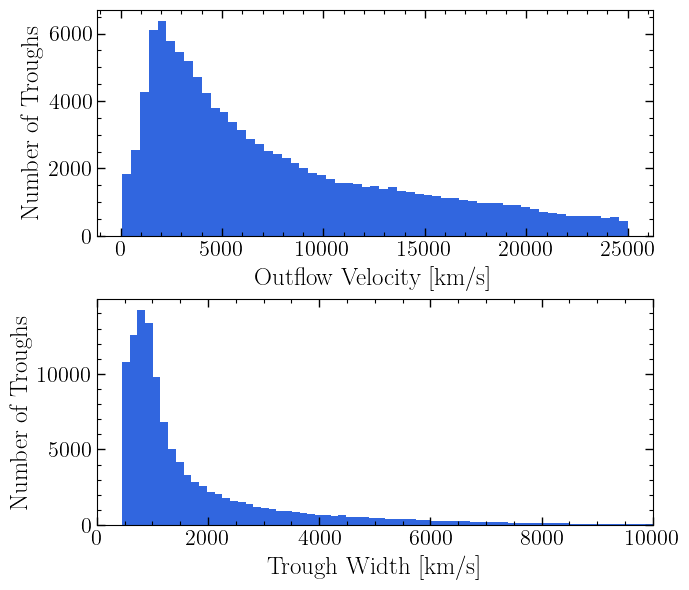

In [4]:
cmap = cm.freeze
color = cmap.colors[120]
fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=False)

# Top plot - linear
dat = trough_table['POSMIN']
ax = axs[0]
ax.hist(dat, bins='scott', color=color)
ax.set_xlabel('Outflow Velocity [km/s]', fontsize=18)
ax.set_ylabel('Number of Troughs', fontsize=18)
ax.tick_params(axis='both', direction='in', length=6, width=1, top=True, right=True, labelsize=16)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True, labelsize=16)

# Bottom plot - logarithmic
dat = trough_table['WIDTH']
ax = axs[1]
bins = np.logspace(np.log10(dat[dat > 0].min()), np.log10(dat.max()), 35)
ax.hist(dat, bins='scott', color=color)
# ax.set_xscale('log')
ax.set_xlabel('Trough Width [km/s]', fontsize=18)
ax.set_ylabel('Number of Troughs', fontsize=18)
ax.tick_params(axis='both', direction='in', length=6, width=1, top=True, right=True, labelsize=16)
ax.minorticks_on()
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True, labelsize=16)
ax.set_xlim(0, 10000)
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.28)
plt.savefig("Results/Figures/redShift.png", bbox_inches="tight", dpi=300)
plt.show()

### Determine the statistical properties for the chosen troughs

4600 uped by 2

In [5]:
if compute_real_data:
    trough_stats, stacking_spectra = LineLocking.get_real_spectra_stats(trough_table, specdir, Continuum_Type='PCA', balfilename=balfilename, pcaeigenfile=pcaeigenfile, meanContinuum=meancontinuum)
    # Save the distributions
    trough_stats.to_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_{save_file}.csv", index=False, sep=',')
    np.savetxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_{save_file}.csv', np.array(stacking_spectra), delimiter=',')

    print(f"Rejected {trough_stats["Rejection Counter"][0]} troughs. {trough_table.shape[0]-trough_stats["Rejection Counter"][0]} remaining.")
    print("Finished Calculating Distributions!")

# Load in the Data

In [6]:
# Create a combined KDE from the saved distributions
data = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_{save_file}.csv")
values = np.vstack([data['Blue Depths'], data['Red Depths'], data['Noises'], data['Trough Depths'], data['Trough Widths'], data['Triplet Depths'], data['Trough Center']])
master_KDE = gaussian_kde(values, bw_method=1/8)

### Show the Distributions

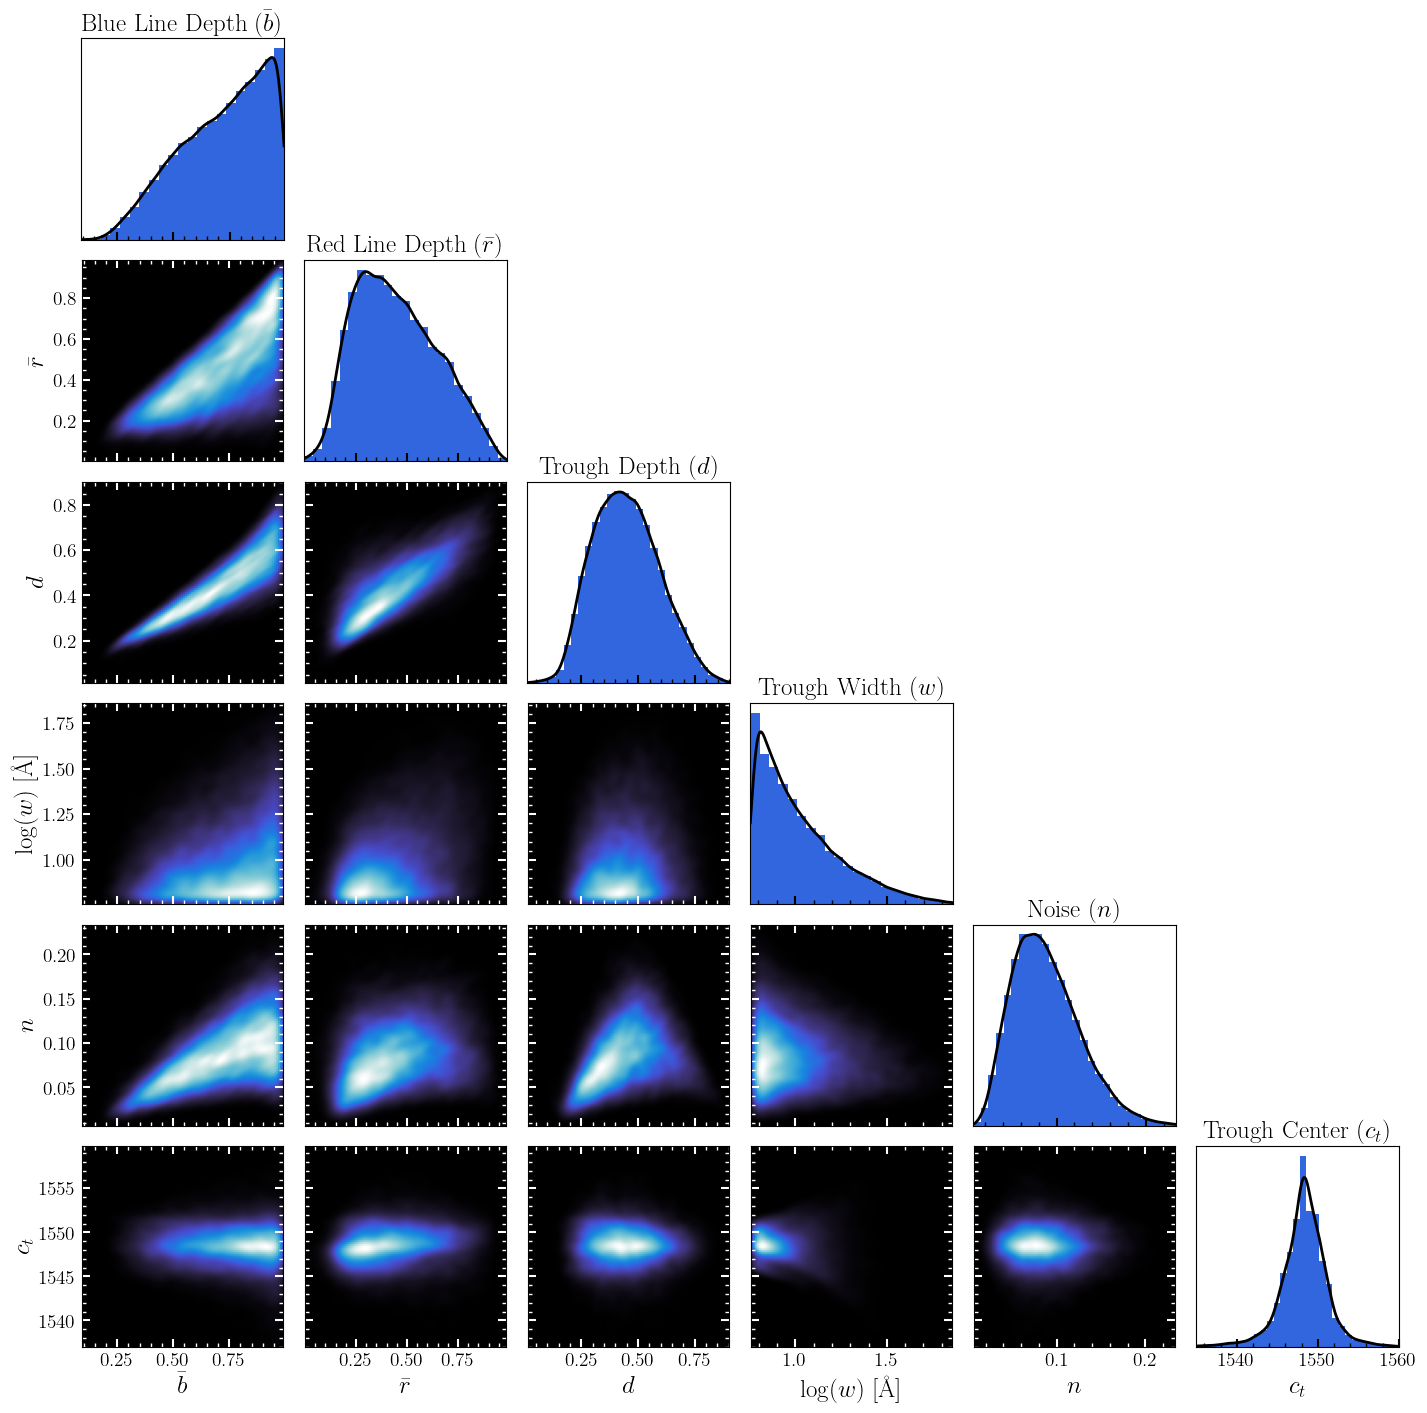

In [7]:
def make_2D_PDF(data1, data2):
    # Make the 2D Combined PDF
    KDE = gaussian_kde(np.vstack([data1, data2]), bw_method=1/8)
    data1_clipped = sigma_clip(data1, sigma=4, maxiters=5)
    xmin = data1_clipped.min()
    xmax = data1_clipped.max()
    data2_clipped = sigma_clip(data2, sigma=4, maxiters=5)
    ymin = data2_clipped.min()
    ymax = data2_clipped.max()
    X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(KDE.pdf(positions).T, X.shape)
    return np.rot90(Z), [xmin, xmax, ymin, ymax], (xmax-xmin)/(ymax-ymin)
def make_1D_PDF(data):
    xmin = data.min()
    xmax = data.max()
    eval_points = np.linspace(xmin, xmax, 1000)
    KDE = gaussian_kde(data)
    return eval_points, KDE.pdf(eval_points)

cmap = cm.freeze
color = cmap.colors[120]
line_color = 'k'#cmap.colors[100]

scott_bins1 = plt.hist(data["Blue Depths"], density=True, bins='scott')[1]
plt.close()
bins1 = int(len(scott_bins1)/2)
scott_bins2 = plt.hist(data["Red Depths"], density=True, bins='scott')[1]
plt.close()
bins2 = int(len(scott_bins2)/2)
scott_bins3 = plt.hist(data["Trough Depths"], density=True, bins='scott')[1]
plt.close()
bins3 = int(len(scott_bins3)/2)
scott_bins4 = plt.hist(data["Trough Widths"], density=True, bins='scott')[1]
plt.close()
bins4 = int(len(scott_bins4)/2)
scott_bins5 = plt.hist(data["Noises"], density=True, bins='scott')[1]
plt.close()
bins5 = int(len(scott_bins5)/2)
scott_bins6 = plt.hist(data["Trough Center"], density=True, bins='scott')[1]
plt.close()
bins6 = int(len(scott_bins6)/2)

labelsize=18
ticksize = 14


fig, axs = plt.subplots(6, 6, figsize=(17,17), sharex='col', squeeze=True)

# Remove unwanted plots and adjust ticks
for i in range(6):
    for j in range(6):
        axs[i,j].tick_params(labelsize=ticksize, width=1.5, length=6, which='both', direction='in')  # Make ticks more notable
        if i != j:
            axs[i,j].tick_params(axis='x', which='both', direction='in', color='w', top=True, bottom=True)  # Top and bottom ticks
            axs[i,j].tick_params(axis='y', which='both', direction='in', color='w', left=True, right=True)  # Left and right ticks
        axs[i,j].minorticks_on()  # Enable minor ticks
        axs[i,j].tick_params(axis='both', which='minor', width=1, length=3)  # Subticks customization
        if i < j:
            axs[i,j].set_axis_off()


axs[0,0].hist(data["Blue Depths"], density=True, bins=bins1, color=color)
x,y = make_1D_PDF(data["Blue Depths"])
axs[0,0].plot(x,y, c=line_color, lw=2)
axs[0,0].set_title('Blue Line Depth '+r'($\bar{b}$)', fontsize=labelsize)
axs[0,0].set_yticklabels([])
axs[0,0].yaxis.set_major_locator(ticker.NullLocator())
b_r_PDF, ext, asp = make_2D_PDF(data['Blue Depths'], data['Red Depths'])
axs[1,0].imshow(b_r_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[1,0].set_ylabel(r"$\bar{r}$", fontsize=labelsize)
b_d_PDF, ext, asp = make_2D_PDF(data['Blue Depths'], data['Trough Depths'])
axs[2,0].imshow(b_d_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[2,0].set_ylabel("$d$", fontsize=labelsize)
b_w_PDF, ext, asp = make_2D_PDF(data['Blue Depths'], data['Trough Widths'])
axs[3,0].imshow(b_w_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[3,0].set_ylabel(r"$\log(w)$ [\AA]", fontsize=labelsize)
b_n_PDF, ext, asp = make_2D_PDF(data['Blue Depths'], data['Noises'])
axs[4,0].imshow(b_n_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[4,0].set_ylabel("$n$", fontsize=labelsize)
axs[5,0].set_xlabel(r'$\bar{b}$', fontsize=labelsize)
b_c_PDF, ext, asp = make_2D_PDF(data['Blue Depths'], data['Trough Center'])
axs[5,0].imshow(b_c_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[5,0].set_ylabel(r"$c_t$", fontsize=labelsize)
axs[5,0].set_xlabel(r'$\bar{b}$', fontsize=labelsize)

axs[1,1].hist(data["Red Depths"], density=True, bins=bins2, color=color)
axs[1,1].yaxis.set_major_locator(ticker.NullLocator())
x,y = make_1D_PDF(data["Red Depths"])
axs[1,1].plot(x,y, c=line_color, lw=2)
axs[1,1].set_title('Red Line Depth '+r'($\bar{r}$)', fontsize=labelsize)
axs[1,1].set_yticklabels([])
r_d_PDF, ext, asp = make_2D_PDF(data['Red Depths'], data['Trough Depths'])
axs[2,1].imshow(r_d_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[2,1].set_yticklabels([])
r_w_PDF, ext, asp = make_2D_PDF(data['Red Depths'], data['Trough Widths'])
axs[3,1].imshow(r_w_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[3,1].set_yticklabels([])
r_n_PDF, ext, asp = make_2D_PDF(data['Red Depths'], data['Noises'])
axs[4,1].imshow(r_n_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[4,1].set_yticklabels([])
axs[5,1].set_xlabel(r'$\bar{r}$', fontsize=labelsize)
r_c_PDF, ext, asp = make_2D_PDF(data['Red Depths'], data['Trough Center'])
axs[5,1].imshow(r_c_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[5,1].set_yticklabels([])

axs[2,2].hist(data["Trough Depths"], density=True, bins=bins3, color=color)
axs[2,2].yaxis.set_major_locator(ticker.NullLocator())
x,y = make_1D_PDF(data["Trough Depths"])
axs[2,2].plot(x,y, c=line_color, lw=2)
axs[2,2].set_title('Trough Depth '+r'($d$)', fontsize=labelsize)
axs[2,2].set_yticklabels([])
d_w_PDF, ext, asp = make_2D_PDF(data['Trough Depths'], data['Trough Widths'])
axs[3,2].imshow(d_w_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[3,2].set_yticklabels([])
d_n_PDF, ext, asp = make_2D_PDF(data['Trough Depths'], data['Noises'])
axs[4,2].imshow(d_n_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[4,2].set_yticklabels([])
axs[5,2].set_xlabel('$d$', fontsize=labelsize)
d_c_PDF, ext, asp = make_2D_PDF(data['Trough Depths'], data['Trough Center'])
axs[5,2].imshow(d_c_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[5,2].set_yticklabels([])

axs[3,3].hist(data["Trough Widths"], density=True, bins=bins4, color=color)
axs[3,3].yaxis.set_major_locator(ticker.NullLocator())
x,y = make_1D_PDF(data["Trough Widths"])
axs[3,3].plot(x,y, c=line_color, lw=2)
axs[3,3].set_title('Trough Width '+r'($w$)', fontsize=labelsize)
axs[3,3].set_yticklabels([])
w_n_PDF, ext, asp = make_2D_PDF(data['Trough Widths'], data['Noises'])
axs[4,3].imshow(w_n_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[4,3].set_yticklabels([])
axs[5,3].set_xlabel(r'$\log(w)$ [\AA]', fontsize=labelsize)
w_c_PDF, ext, asp = make_2D_PDF(data['Trough Widths'], data['Trough Center'])
axs[5,3].imshow(w_c_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[5,3].set_yticklabels([])

axs[4,4].hist(data["Noises"], density=True, bins=bins5, color=color)
axs[4,4].yaxis.set_major_locator(ticker.NullLocator())
x,y = make_1D_PDF(data["Noises"])
axs[4,4].plot(x,y, c=line_color, lw=2)
#axs[4,4].set_xlim(0,0.3)
axs[4,4].set_title('Noise ($n$)', fontsize=labelsize)
axs[4,4].set_yticklabels([])
axs[5,4].set_xlabel(r'$n$', fontsize=labelsize)
n_c_PDF, ext, asp = make_2D_PDF(data['Noises'], data['Trough Center'])
axs[5,4].imshow(n_c_PDF, extent=ext, aspect=asp, cmap=cmap)
axs[5,4].set_yticklabels([])

axs[5,5].hist(data["Trough Center"], density=True, bins=bins6, color=color)
axs[5,5].yaxis.set_major_locator(ticker.NullLocator())
x,y = make_1D_PDF(data["Trough Center"])
axs[5,5].plot(x,y, c=line_color, lw=2)
axs[5,5].set_title('Trough Center ($c_t$)', fontsize=labelsize)
axs[5,5].set_yticklabels([])
axs[5,5].set_xlim(1535,1560)
axs[5,5].set_xlabel('$c_t$', fontsize=labelsize)

plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig("./Results/Figures/corner_plot.png", bbox_inches="tight", dpi=300)
plt.show()

### Show an example of a mock trough

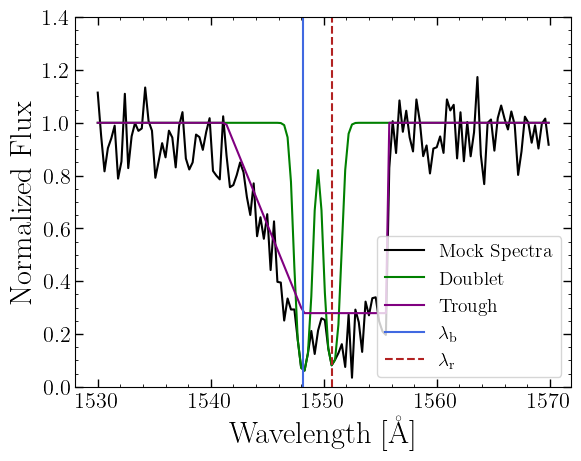

In [8]:
# Create Mock Spectra
wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1530, 1570), KDE=master_KDE, return_params=True)

# Create doublet to overlay
b, r = LineLocking.Convert_to_depth_params(params['Blue Depth'][0], params['Red Depth'][0], absorption_width=0.5)
doublet_overlay = []
for wl in wavelengths:
    doublet_overlay.append(LineLocking.Doublet(wl, 0.5, b, r))
# Create Trough to overlay
boxcar_overlay = []
for wl in wavelengths:
    boxcar_overlay.append(LineLocking.Boxcar(wl, params["Trough Center"][0], params["Trough Depth"][0], params["Trough Width"][0], params['Red Depth'][0], params['Triplet Depth'][0], Type='standard'))

# Plot Mock Spectra
labelsize=22
ticksize = 20
plt.plot(wavelengths, Flux, c='k', label='Mock Spectra')
plt.plot(wavelengths, doublet_overlay, c='green', label='Doublet')
plt.plot(wavelengths, boxcar_overlay, c='purple', label='Trough')
plt.axvline(x=1548.2, c='royalblue', linestyle='-', label=r'$\lambda_\mathrm{b}$')
plt.axvline(x=1550.7, c='firebrick', linestyle='--', label=r'$\lambda_\mathrm{r}$')
plt.xlabel(r'Wavelength [\AA]', fontsize=labelsize)
plt.ylabel('Normalized Flux', fontsize=labelsize)
plt.tick_params(labelsize=ticksize)
plt.legend(fontsize=ticksize-6, loc='lower right')
plt.tick_params(axis='both', direction='in', length=6, width=1, labelsize=ticksize-4, top=True, right=True)
plt.ylim(0,1.4)
plt.minorticks_on()
plt.tick_params(axis='both', which='minor', direction='in', top=True, right=True)
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig("./Results/Figures/Mock_Spectrum_Example.png", bbox_inches="tight", dpi=300)
plt.show()

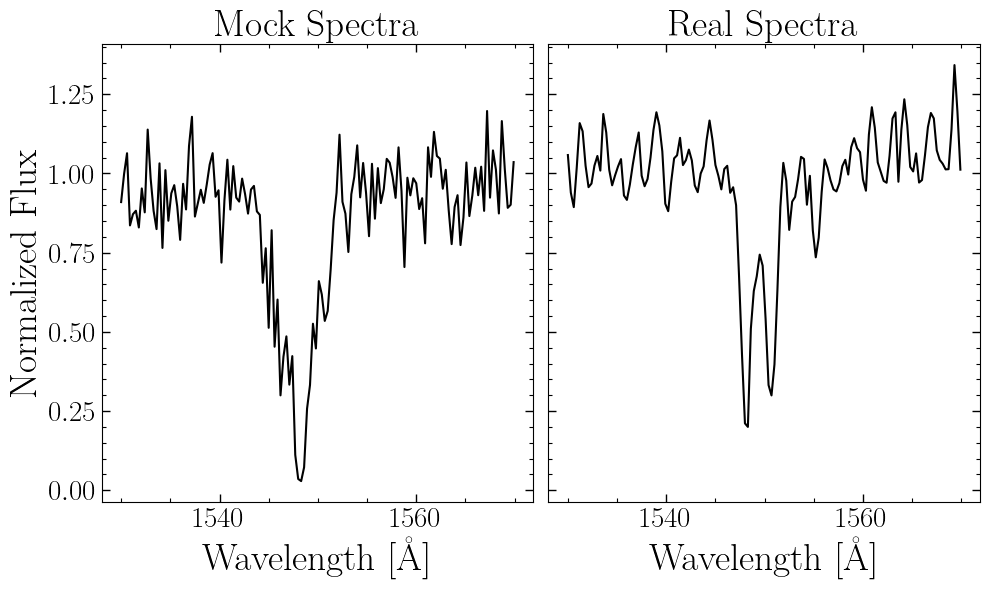

In [9]:
# trough_table_ridx = trough_table.reset_index(drop=True)

# lowest_Z = trough_table_ridx.sort_values('Z_PCA').head(6000)
# lowZ_LowSNR = lowest_Z.sort_values('FMIN').head(500)
# possible_troughs = lowZ_LowSNR.index

#possible_troughs = [55315, 20148, 48894, 9864, 30895,70386,50115,13301,39566]
possible_troughs = [50115] #80897


for num in possible_troughs:

    specname = LineLocking.determine_spec_fileName(trough_table.iloc[num], specdir)
    current_spec_data = LineLocking.read_spec(specname)

    # Shift Spectrum to the trough restframe
    current_spec_data['WAVE_CIV'] = current_spec_data['WAVE_OBS'] /( 1. + trough_table.iloc[num]['Z_MIN'])

    # Rebin everything into equally spaced 0.3 Angstrom bins
    rebin_wavelengths = np.arange(1530., 1570., 0.3)
    rebin_flux = np.zeros(len(rebin_wavelengths),dtype=float)
    rebin_flux = np.interp(rebin_wavelengths, current_spec_data['WAVE_CIV'].values, current_spec_data['FLUX'])

    # Get the PCA Fit
    rest_wl_QSO = current_spec_data['WAVE_OBS'] /( 1. + trough_table.iloc[num]['Z_PCA'])
    pca_model = LineLocking.read_PCA_cont(balfilename, pcaeigenfile, trough_table, num, rest_wl_QSO)
    # Rebin
    rebin_model = np.zeros(len(rebin_wavelengths), dtype=float)
    rebin_model = np.interp(rebin_wavelengths, current_spec_data['WAVE_CIV'].values, pca_model)

    # Divide by continuum
    flux_norm = rebin_flux/rebin_model

    # Make Mock
    wls, Flux = LineLocking.generate_spectra((1530, 1570), master_KDE)

    fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
    fontsizes = 27
    axs[1].set_title(f"Real Spectra", fontsize=fontsizes)
    axs[1].plot(rebin_wavelengths, flux_norm, 'k')
    axs[1].set_xlabel(r'Wavelength [\AA]', fontsize=fontsizes)
    axs[1].tick_params(axis='both', direction='in', length=6, width=1, labelsize=fontsizes-6, top=True, right=True)
    axs[1].minorticks_on()
    axs[1].tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)
    axs[0].set_ylabel('Normalized Flux', fontsize=fontsizes)
    axs[0].set_title("Mock Spectra", fontsize=fontsizes)
    axs[0].plot(wls, Flux, 'k')
    axs[0].set_xlabel(r'Wavelength [\AA]', fontsize=fontsizes)
    axs[0].tick_params(axis='both', direction='in', length=6, width=1, labelsize=fontsizes-6, top=True, right=True)
    axs[0].minorticks_on()
    axs[0].tick_params(axis='both', which='minor', direction='in', length=3, width=0.8, top=True, right=True)
    plt.tight_layout()
    #plt.savefig("./Results/Figures/Real_vs_Mock.png", bbox_inches="tight", dpi=300)
    plt.show()


### Create an equal number of mock spectra and calculate their statistical distributions

In [10]:
MOCK_STACKING = []   
MOCK_STATS = []
for _ in range(1): 
    # Set up a pandas dataframe to act as a table to hold all of the mock spectra
    Mock_Trough_Table = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise", 'Trough Center'])

    # Create and store thousands of mock spectra 
    print(f'Creating a Sample of {data.shape[0]} Mock Spectra...')
    for k in tqdm(range(data.shape[0])):
        wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1548.2-60*0.3, 1548.2+60*0.3), KDE=master_KDE, return_params=True, triplet=use_mock_triplet)
        Mock_Trough_Table.loc[ len(Mock_Trough_Table) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0], params['Trough Center'][0]]

    # Perform the statistics
    print(f'Building up Mock Statistics...')
    mock_stats, mock_stacking_spectra = LineLocking.get_mock_spectra_stats(Mock_Trough_Table)
    print(f'Finished! {mock_stats['Rejection Counter'][0]} troughs rejected.')
    MOCK_STACKING.append(mock_stacking_spectra)
    MOCK_STATS.append(mock_stats)


Creating a Sample of 29332 Mock Spectra...


  0%|          | 0/29332 [00:00<?, ?it/s]

Building up Mock Statistics...


  0%|          | 0/29332 [00:00<?, ?it/s]

Finished! 0 troughs rejected.


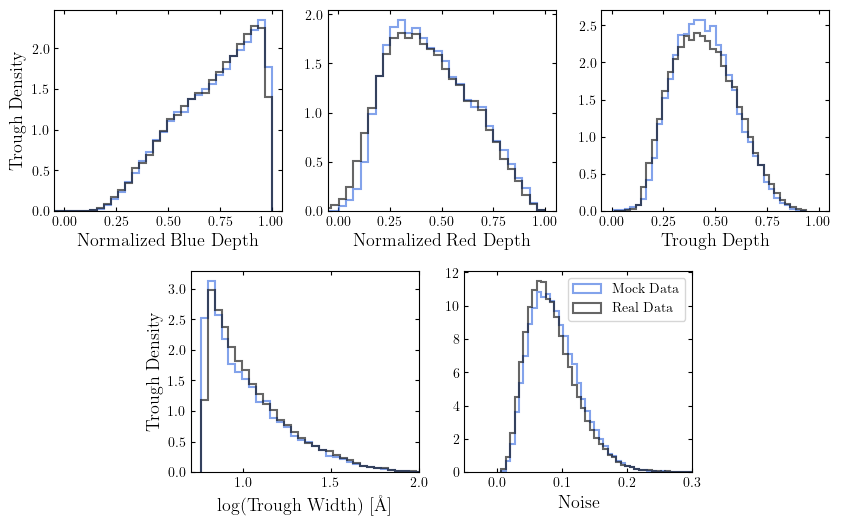

In [11]:
bartype = 'step'
labelsize = 13
ticksize = 10
lw=1.5
cmap = cm.freeze
c2 = cmap.colors[120]
c1 = 'k'
bins_scott1 = plt.hist([mock_stats['Blue Depths'], data['Blue Depths']], density=True, bins='scott')[1]
plt.close()
bins1=int(len(bins_scott1)/2)

bins_scott2 = plt.hist([mock_stats['Red Depths'], data['Red Depths']], density=True, bins='scott')[1]
plt.close()
bins2=int(len(bins_scott2)/2)

bins_scott3 = plt.hist([mock_stats['Trough Depths'], data['Trough Depths']], density=True, bins='scott')[1]
plt.close()
bins3=int(len(bins_scott3)/2)

bins_scott4 = plt.hist([mock_stats['Trough Widths'], data['Trough Widths']], density=True, bins='scott')[1]
plt.close()
bins4=int(len(bins_scott4)/2)

bins_scott5 = plt.hist([mock_stats['Noises'], data['Noises']], density=True, bins='scott')[1]
plt.close()
bins5=int(len(bins_scott5)/2)

# Create figure and axes
fig = plt.figure(figsize=(10, 6))
ax1 = plt.subplot2grid(shape=(2,6), loc=(0,0), colspan=2)
ax2 = plt.subplot2grid((2,6), (0,2), colspan=2)
ax3 = plt.subplot2grid((2,6), (0,4), colspan=2)
ax4 = plt.subplot2grid((2,6), (1,1), colspan=2)
ax5 = plt.subplot2grid((2,6), (1,3), colspan=2)

# Plot data
ax1.hist([mock_stats['Blue Depths'], data['Blue Depths']], density=True, alpha=0.6, bins=bins1, color=[c1,c2], histtype=bartype, label=['Mock Data', 'Real Data'], linewidth=lw)
ax1.set_xlabel('Normalized Blue Depth', fontsize=labelsize)
ax1.set_ylabel('Trough Density', fontsize=labelsize)
ax1.set_xlim(-0.05, 1.05)

ax2.hist([mock_stats['Red Depths'], data['Red Depths']], density=True, alpha=0.6, bins=bins2, color=[c1,c2], histtype=bartype, label=['Mock Data', 'Real Data'], linewidth=lw)
ax2.set_xlabel('Normalized Red Depth', fontsize=labelsize)
ax2.set_xlim(-0.05, 1.05)

ax3.hist([mock_stats['Trough Depths'], data['Trough Depths']], density=True, alpha=0.6, bins=bins3, color=[c1,c2], histtype=bartype, label=['Mock Data', 'Real Data'], linewidth=lw)
ax3.set_xlabel('Trough Depth', fontsize=labelsize)
ax3.set_xlim(-0.05, 1.05)

ax4.hist([mock_stats['Trough Widths'], data['Trough Widths']], density=True, alpha=0.6, bins=bins4, color=[c1,c2], histtype=bartype, label=['Mock Data', 'Real Data'], linewidth=lw)
ax4.set_xlabel(r'log(Trough Width) [\AA]', fontsize=labelsize)
ax4.set_ylabel('Trough Density', fontsize=labelsize)
ax4.set_xlim(0.7, 2.)

ax5.hist([mock_stats['Noises'], data['Noises']], density=True, alpha=0.6, bins=bins5, color=[c1,c2], histtype=bartype, label=['Mock Data', 'Real Data'], linewidth=lw)
ax5.set_xlabel('Noise', fontsize=labelsize)
ax5.set_xlim(-0.05, 0.3)

# Set tick parameters to adjust tick labels, tick directions, and sizes
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.tick_params(axis='both', which='both', direction='in', length=3, width=0.8, labelsize=ticksize, top=True, right=True, labelleft=True, labelbottom=True)

# Add a single legend for all plots
ax5.legend(['Mock Data', 'Real Data'], loc='upper right', fontsize=ticksize)

# Adjust layout and show
plt.subplots_adjust(wspace=0.5, hspace=0.3)
plt.savefig("./Results/Figures/Parameter_Comparison_Plot.png", bbox_inches="tight", dpi=300)
plt.show()


### Calculate and Compare some statistical properties of the distributions

In [12]:
def errBrack(value, error):
    """
    Format a value with its uncertainty in parentheses.
    Keeps 1 significant digit in the error, and matches the value precision accordingly.
    Example: 3.14159 ± 0.0271 → "3.14(3)"
    """
    if error == 0 or np.isnan(error):
        return f"{value}(0)"

    # Get exponent of the error
    exponent = int(np.floor(np.log10(abs(error))))
    sig_digit = round(error, -exponent)  # 1 significant digit

    # Round value to match error's decimal precision
    decimals = -exponent if exponent < 0 else 0
    rounded_value = round(value, decimals)
    rounded_error = int(round(error / (10 ** exponent)))  # 1-digit integer

    # Format as string
    value_str = f"{rounded_value:.{decimals}f}" if decimals > 0 else str(int(rounded_value))
    return f"{value_str}({rounded_error})"

def relative_difference_error(real, mock, sigma_real, sigma_mock):
    if real == 0:
        return np.nan  # Avoid division by zero

    term1 = (100 * mock / real**2)**2 * sigma_real**2
    term2 = (100 / real)**2 * sigma_mock**2
    return np.sqrt(term1 + term2)



# Initialize rows of the table (lists)
Real_Mean = ['Real Mean']
Mock_Mean = ['Mock Mean']
Relative_Mean_Ratio = ['Relative Mean Ratio']
Real_Std = ['Real Std']
Mock_Std = ['Mock Std']
Relative_Std_Ratio = ['Relative Std Ratio']
Real_Skew = ['Real Skew']
Mock_Skew = ['Mock Skew']
Relative_Skew_Ratio = ['Relative Skew Ratio']
Real_Kurtosis = ['Real Kurtosis']
Mock_Kurtosis = ['Mock Kurtosis']
Relative_Kurtosis_Ratio = ['Relative Kurtosis Ratio']

columns = ['Blue Depths', 'Red Depths', 'Trough Depths', 'Trough Widths', 'Noises']

for col in columns:
    # Get real and mock stats for the current column
    real = data[col]
    mean_real = real.mean()
    std_real = real.std()
    skew_real = skew(real)
    kurt_real = kurtosis(real)

    mean_mocks = []
    std_mocks = []
    skew_mocks = []
    kurt_mocks = []
    for m in range(len(MOCK_STATS)):
        mock = MOCK_STATS[m][col]
        mean_mocks.append(mock.mean())
        std_mocks.append(mock.std())
        skew_mocks.append(skew(mock))
        kurt_mocks.append(kurtosis(mock))
    
    mean_mock = np.mean(mean_mocks)
    std_mock = np.mean(std_mocks)
    skew_mock = np.mean(skew_mocks)
    kurt_mock = np.mean(kurt_mocks)

    # Append to respective rows
    Real_Mean.append(errBrack(mean_real, std_real/np.sqrt(len(real))))
    Mock_Mean.append(errBrack(mean_mock, np.std(mean_mocks)))
    Relative_Mean_Ratio.append(f"{errBrack(100 * (mean_real - mean_mock) / mean_real, relative_difference_error(mean_real, mean_mock, std_real/np.sqrt(len(real)), np.std(mean_mocks)))}%")

    Real_Std.append(errBrack(std_real, std_real/np.sqrt(2*len(real))))
    Mock_Std.append(errBrack(std_mock, np.std(std_mocks)))
    Relative_Std_Ratio.append(f"{errBrack(100 * (std_real - std_mock) / std_real, relative_difference_error(std_real, std_mock, std_real/np.sqrt(2*len(real)), np.std(std_mocks)))}%")

    Real_Skew.append(errBrack(skew_real, np.sqrt(6/len(real))))
    Mock_Skew.append(errBrack(skew_mock, np.std(skew_mocks)))
    Relative_Skew_Ratio.append(f"{errBrack(100 * (skew_real - skew_mock) / skew_real, relative_difference_error(skew_real, skew_mock, np.sqrt(6/len(real)), np.std(skew_mocks)))}%")

    Real_Kurtosis.append(errBrack(kurt_real, np.sqrt(24/len(real))))
    Mock_Kurtosis.append(errBrack(kurt_mock, np.std(kurt_mocks)))
    Relative_Kurtosis_Ratio.append(f"{errBrack(100 * (kurt_real - kurt_mock) / kurt_real, relative_difference_error(kurt_real, kurt_mock, np.sqrt(24/len(real)), np.std(kurt_mocks)))}%")

# Build the table
rows = [Real_Mean,
        Mock_Mean,
        Relative_Mean_Ratio,
        Real_Std,
        Mock_Std,
        Relative_Std_Ratio,
        Real_Skew,
        Mock_Skew,
        Relative_Skew_Ratio,
        Real_Kurtosis,
        Mock_Kurtosis,
        Relative_Kurtosis_Ratio]

headers = ['Statistic'] + columns

# Print the table
print(f"{len(real)}")
print(tabulate(rows, headers=headers, tablefmt="latex"))

29332
\begin{tabular}{llllll}
\hline
 Statistic               & Blue Depths            & Red Depths             & Trough Depths          & Trough Widths          & Noises                 \\
\hline
 Real Mean               & 0.718(1)               & 0.450(1)               & 0.4486(8)              & 1.027(1)               & 0.0892(2)              \\
 Mock Mean               & 0.7143304487525386(0)  & 0.43522642758112506(0) & 0.44902914261294063(0) & 1.0455984731360386(0)  & 0.08492933540090199(0) \\
 Relative Mean Ratio     & 0.5(2)\%                & 3.3(2)\%                & -0.1(2)\%               & -1.8(1)\%               & 4.8(2)\%                \\
 Real Std                & 0.1908(8)              & 0.1975(8)              & 0.1428(6)              & 0.2274(9)              & 0.0383(2)              \\
 Mock Std                & 0.19040761268243897(0) & 0.20360307417851445(0) & 0.15143224209937375(0) & 0.22559610213356848(0) & 0.03839230960307788(0) \\
 Relative Std Ratio      & 0.2(4)

### Stack the real/mock spectra and compare

In [13]:
def nanweighted_mean_std(data, weights, axis=0):
    data = np.asarray(data)
    weights = np.asarray(weights)

    # Expand weights to match data dimensions along the averaging axis
    if axis == 0 and weights.ndim == 1:
        weights = weights[:, np.newaxis]
    elif axis == 1 and weights.ndim == 1:
        weights = weights[np.newaxis, :]

    # Mask NaNs
    mask = ~np.isnan(data)
    safe_data = np.where(mask, data, 0)
    safe_weights = np.where(mask, weights, 0)

    # Compute weighted mean
    weighted_sum = np.sum(safe_data * safe_weights, axis=axis)
    sum_weights = np.sum(safe_weights, axis=axis)
    with np.errstate(divide='ignore', invalid='ignore'):
        mean = np.divide(weighted_sum, sum_weights)
        mean[sum_weights == 0] = np.nan

    # Expand mean back to data shape for broadcasting
    mean_broadcast = np.expand_dims(mean, axis=axis)
    squared_diff = (safe_data - mean_broadcast) ** 2

    # Compute weighted standard deviation
    weighted_squared_diff = squared_diff * safe_weights
    variance = np.sum(weighted_squared_diff, axis=axis) / sum_weights
    std = np.sqrt(variance)
    std[sum_weights == 0] = np.nan

    return mean, std


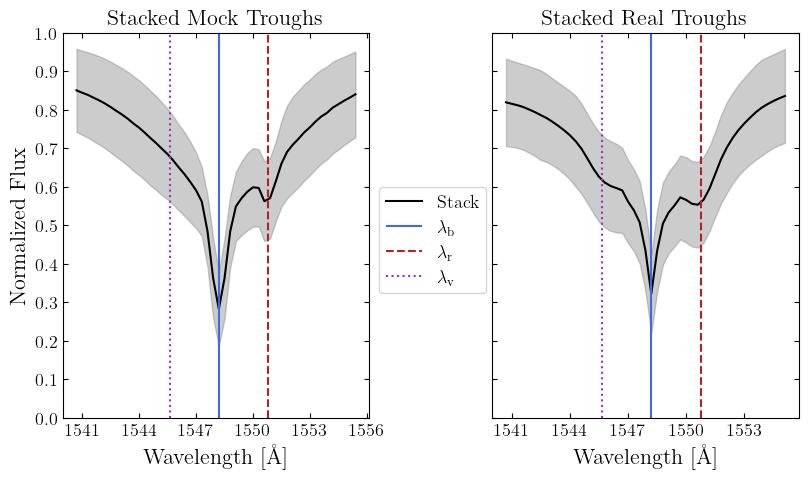

In [14]:
#### Stack the Mock Spectra
stacked_mocks, stacked_mocks_error = nanweighted_mean_std(np.vstack(mock_stacking_spectra), mock_stats["Weights"], axis=0)
#stacked_mocks = np.mean(np.vstack(mock_stacking_spectra), axis=0)
#stacked_mocks_error = np.std(np.vstack(mock_stacking_spectra), axis=0)/2
stacking_wavelengths_mocks = np.arange(1548.2-25*0.3, 1548.2+25*0.3, 0.3)

#### Stack the Real Spectra
stacking_spectra_data = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_{save_file}.csv', delimiter=',')
stacked_spectra_weighted, stacked_spectra_error = nanweighted_mean_std(np.vstack(stacking_spectra_data), data["Weights"], axis=0)
#stacked_spectra = np.nanmean(np.vstack(stacking_spectra_data), axis=0)
#stacked_spectra_error = np.nanstd(np.vstack(stacking_spectra_data), axis=0)/2
stacking_wavelengths = np.arange(900.2, 1599.8, 0.3)
CIV_wlMin = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[0]))
CIV_wlMax = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[-1]))


# Plot the Stacks
labelsize=16
ticksize = 13
fig, axes = plt.subplots(1,2, figsize=(9.5, 5), sharey=True)
axes[0].plot(stacking_wavelengths_mocks, stacked_mocks, c='k')
axes[0].fill_between(stacking_wavelengths_mocks, stacked_mocks-stacked_mocks_error/2, stacked_mocks+stacked_mocks_error/2, color='grey', alpha=0.4)
axes[0].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[0].set_ylabel('Normalized Flux', fontsize=labelsize)
axes[0].set_title('Stacked Mock Troughs', fontsize=labelsize)
axes[0].set_ylim(0.0, 1)
axes[0].set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
axes[0].set_xticks([1541,1544,1547,1550,1553,1556])
axes[0].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-')
axes[0].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--')
axes[0].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':')
axes[0].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)

axes[1].plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra_weighted[CIV_wlMin:CIV_wlMax], c='k', label='Stack')
axes[1].fill_between(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra_weighted[CIV_wlMin:CIV_wlMax]-stacked_spectra_error[CIV_wlMin:CIV_wlMax]/2, stacked_spectra_weighted[CIV_wlMin:CIV_wlMax]+stacked_spectra_error[CIV_wlMin:CIV_wlMax]/2, color='grey', alpha=0.4)
axes[1].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[1].set_title('Stacked Real Troughs', fontsize=labelsize)
axes[1].set_ylim(0.0, 1)
axes[1].set_xticks([1541,1544,1547,1550,1553,1556])
axes[1].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$')
axes[1].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
axes[1].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$')
axes[1].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
axes[1].legend(fontsize=ticksize, loc='lower right', bbox_to_anchor=(0.01, 0.3))

plt.subplots_adjust(wspace=0.4)
plt.savefig("./Results/Figures/Big_Stack.png", bbox_inches="tight", dpi=300)
plt.show()


# np.savez('/Users/bradengail/Documents/Trip.npz',
#          Mockwavelengths=stacking_wavelengths_mocks,
#          MockError=stacked_mocks_error,
#          Mockstacks=stacked_mocks
#          )


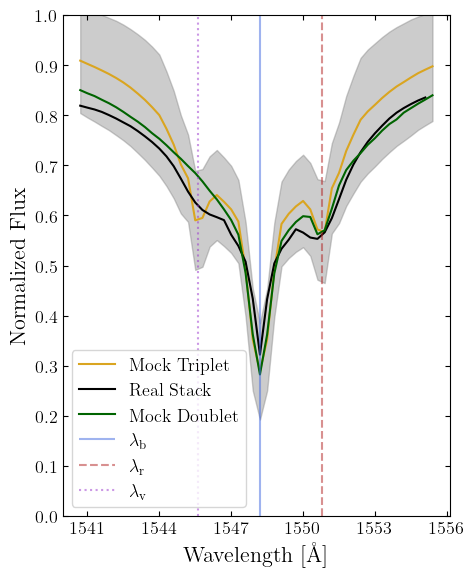

In [15]:
t = np.load("/Users/bradengail/Documents/Trip.npz")

labelsize=16
ticksize = 13
fig, ax = plt.subplots(1,1, figsize=(5, 6.5), sharey=True)
ax.plot(t['Mockwavelengths'], t['Mockstacks'], label='Mock Triplet', c='goldenrod')
ax.plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra_weighted[CIV_wlMin:CIV_wlMax], c='k', label='Real Stack')
ax.plot(stacking_wavelengths_mocks, stacked_mocks, c='darkgreen', label='Mock Doublet')
ax.fill_between(t['Mockwavelengths'], t['Mockstacks']-t['MockError']/2, t['Mockstacks']+t['MockError']/2, color='grey', alpha=0.4)
ax.set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
ax.set_ylabel('Normalized Flux', fontsize=labelsize)
ax.set_ylim(0.0, 1)
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
ax.set_xticks([1541,1544,1547,1550,1553,1556])
ax.vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$', alpha=0.5)
ax.vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$', alpha=0.5)
ax.vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$', alpha=0.5)
ax.tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
plt.legend(fontsize=ticksize)
plt.savefig("./Results/Figures/Big_Triplet_Stack.png", bbox_inches="tight", dpi=300)
plt.show()

In [16]:
# Set up a pandas dataframe to act as a table to hold all of the mock spectra
MockTrip_Trough_Table = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])
MockDoub_Trough_Table = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise"])

# Create and store thousands of mock spectra 
print(f'Creating a Sample of {2*data.shape[0]//3} Triplet Mock Spectra...')
for k in tqdm(range(2*data.shape[0]//3)):
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1548.2-60*0.3, 1548.2+60*0.3), KDE=master_KDE, return_params=True, triplet=True)
    MockTrip_Trough_Table.loc[ len(MockTrip_Trough_Table) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]
# Create and store thousands of mock spectra 
print(f'Creating a Sample of {1*data.shape[0]//3} Doublet Mock Spectra...')
for k in tqdm(range(1*data.shape[0]//3)):
    wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1548.2-60*0.3, 1548.2+60*0.3), KDE=master_KDE, return_params=True, triplet=False)
    MockDoub_Trough_Table.loc[ len(MockDoub_Trough_Table) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0]]

# Perform the statistics
print(f'Building up Mock Statistics...')
mockTrip_stats, mockTrip_stacking_spectra = LineLocking.get_mock_spectra_stats(MockTrip_Trough_Table)
print(f'Finished! {mock_stats['Rejection Counter'][0]} troughs rejected.')
# Perform the statistics
print(f'Building up Mock Statistics...')
mockDoub_stats, mockDoub_stacking_spectra = LineLocking.get_mock_spectra_stats(MockDoub_Trough_Table)
print(f'Finished! {mock_stats['Rejection Counter'][0]} troughs rejected.')

mockComb_stacking_spectra = np.vstack((mockTrip_stacking_spectra, mockDoub_stacking_spectra))
mockComb_stats = pd.concat([mockTrip_stats, mockDoub_stats], ignore_index=True)
stacked_mocksComb, stacked_mocksComb_error = nanweighted_mean_std(np.vstack(mockComb_stacking_spectra), mockComb_stats["Weights"], axis=0)



Creating a Sample of 19554 Triplet Mock Spectra...


  0%|          | 0/19554 [00:00<?, ?it/s]

/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/LineLocking_FinalVersion.py:664: RuntimeWarning: invalid value encountered in log
  [np.log(1-triplet_depth)]])


Creating a Sample of 9777 Doublet Mock Spectra...


  0%|          | 0/9777 [00:00<?, ?it/s]

Building up Mock Statistics...


  0%|          | 0/19554 [00:00<?, ?it/s]

KeyError: 'Trough Center'

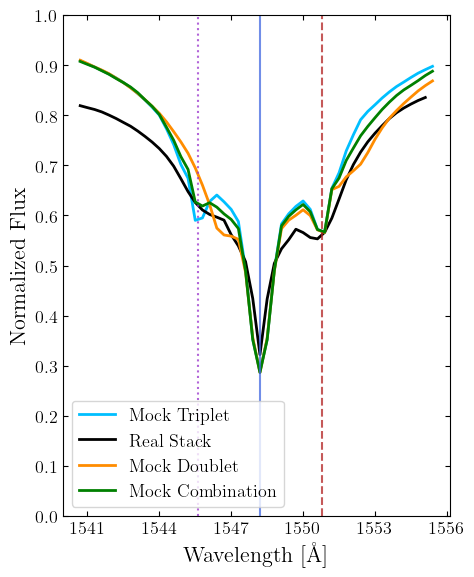

In [ ]:
t = np.load("/Users/bradengail/Documents/Trip.npz")

cmap = plt.get_cmap('PiYG')
n_colors = 3
# Sample colors evenly across the colormap
colors = [cmap(i / (n_colors - 1)) for i in range(n_colors)]

labelsize=16
ticksize = 13
fig, ax = plt.subplots(1,1, figsize=(5, 6.5), sharey=True)
ax.plot(t['Mockwavelengths'], t['Mockstacks'], label='Mock Triplet', c='deepskyblue', lw=2)
ax.plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra_weighted[CIV_wlMin:CIV_wlMax], c='k', label='Real Stack', lw=2)
ax.plot(stacking_wavelengths_mocks, stacked_mocks, c='darkorange', label='Mock Doublet', lw=2)
ax.plot(stacking_wavelengths_mocks, stacked_mocksComb, c='green', label='Mock Combination', lw=2)
#ax.fill_between(t['Mockwavelengths'], t['Mockstacks']-t['MockError']/2, t['Mockstacks']+t['MockError']/2, color='grey', alpha=0.4)
ax.set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
ax.set_ylabel('Normalized Flux', fontsize=labelsize)
ax.set_ylim(0.0, 1)
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
ax.set_xticks([1541,1544,1547,1550,1553,1556])
ax.vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', alpha=0.75)
ax.vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', alpha=0.75)
ax.vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', alpha=0.75)
ax.tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
plt.legend(fontsize=ticksize)
plt.savefig("./Results/Figures/Big_Triplet_Stack.png", bbox_inches="tight", dpi=300)
plt.show()

### Display Some of the Stacking Info

In [ ]:
total_stack_count = mock_stats['Red Stack Counter'][0]+mock_stats['Blue Stack Counter'][0]+mock_stats['Noise Stack Counter'][0]
print(f"Mocks stacked on blue line {np.round(100*mock_stats['Blue Stack Counter'][0]/total_stack_count,2)}% of the time")
print(f"Mocks stacked on red line {np.round(100*mock_stats['Red Stack Counter'][0]/total_stack_count,2)}% of the time")
print(f"Mocks stacked on noise line {np.round(100*mock_stats['Noise Stack Counter'][0]/total_stack_count,2)}% of the time")

b_optical_depth = -np.log(np.interp(1548.2, stacking_wavelengths, stacked_spectra_weighted))
r_optical_depth = -np.log(np.interp(1550.7, stacking_wavelengths, stacked_spectra_weighted))
v_optical_depth = -np.log(np.interp(1545.7, stacking_wavelengths, stacked_spectra_weighted))
print(f"Optical Depth of the Blue Line: {b_optical_depth}")
print(f"Optical Depth of the Red Line: {r_optical_depth}")
print(f"Line Ratio: {b_optical_depth/r_optical_depth}")

Mocks stacked on blue line 92.08% of the time
Mocks stacked on red line 0.13% of the time
Mocks stacked on noise line 7.79% of the time
Optical Depth of the Blue Line: 1.1332981021742152
Optical Depth of the Red Line: 0.5841383031675185
Line Ratio: 1.9401194820282301


## Numerically Solve for the Line Locking Fraction

[0.652118   0.36139383 0.50687609]
x: 0.6521180041327225    b: 1.0177869786773643    r: 0.6794886990092733    Line Ratio: 1.4978718265091766


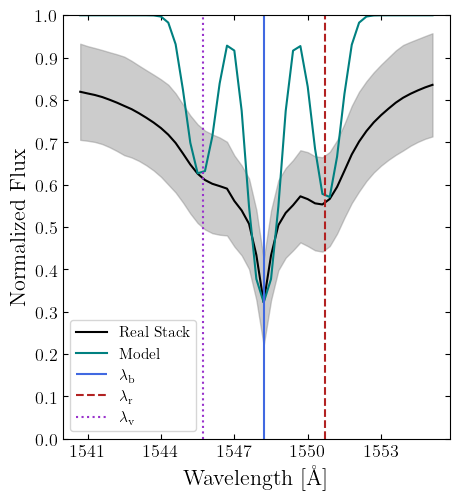

In [17]:
Delta = 0.5     # Width of the absorption lines
C = 0.9         # Cover fraction
xc = 0.01       # Contamination Fraction

def beta(lam):
    global Delta
    return np.exp(-(lam-1548.20)**2/(2*Delta**2))
def alpha(lam):
    global Delta
    return np.exp(-(lam-1550.77)**2/(2*Delta**2))
def gamma(lam):
    global Delta
    return np.exp(-(lam-1545.63)**2/(2*Delta**2))

# Define the system of equations
def system_of_equations(vars):
    x, B, R = vars
    global C
    # Wavelengths of the blue line, red line, and violet line respectively
    lb = 1548.20
    lr = 1550.77
    lv = 1545.63
    # Measured values from the real stack of the blue line, red line, and violet line respectively 
    measured_b = np.interp(1548.20, stacking_wavelengths, stacked_spectra_weighted)
    measured_r = np.interp(1550.77, stacking_wavelengths, stacked_spectra_weighted)
    measured_v = np.interp(1545.63, stacking_wavelengths, stacked_spectra_weighted)
    # 3 equations that comprise the system of equations
    eq1 = x*C*B**(beta(lb))*R**(alpha(lb))*B**(gamma(lb))*R**(beta(lb))-(x+xc-1)*C*B**(beta(lb))*R**(alpha(lb))+xc*C*B**(gamma(lb))*R**(beta(lb))+1-C-measured_b
    eq2 = x*C*B**(beta(lr))*R**(alpha(lr))*B**(gamma(lr))*R**(beta(lr))-(x+xc-1)*C*B**(beta(lr))*R**(alpha(lr))+xc*C*B**(gamma(lr))*R**(beta(lr))+1-C-measured_r
    eq3 = x*C*B**(beta(lv))*R**(alpha(lv))*B**(gamma(lv))*R**(beta(lv))-(x+xc-1)*C*B**(beta(lv))*R**(alpha(lv))+xc*C*B**(gamma(lv))*R**(beta(lv))+1-C-measured_v
    return [eq1, eq2, eq3]

# Solve the system of equations
initial_guess = [0.55, 0.36, 0.5]
solutions = fsolve(system_of_equations, initial_guess)

# Print the solution
print(solutions)
print("x:", solutions[0], "   b:", -np.log(solutions[1]), "   r:", -np.log(solutions[2]), "   Line Ratio:", -np.log(solutions[1])/(-np.log(solutions[2])))
def model(lam, x, b, r):
    I1 = 1-C+C*np.exp(-b*beta(lam)-r*alpha(lam))
    I2 = 1-C+C*np.exp(-b*(beta(lam)+gamma(lam))-r*(alpha(lam)+beta(lam)))
    I3 = 1-C+C*np.exp(-b*gamma(lam)-r*beta(lam))
    return x*I2+(1-x-xc)*I1+xc*I3

model_curve = []
for l in stacking_wavelengths[CIV_wlMin:CIV_wlMax]:
    model_curve.append(model(l, solutions[0], -np.log(solutions[1]), -np.log(solutions[2])))
# Plot the results
plt.figure(figsize=(5, 5.5))
plt.plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra_weighted[CIV_wlMin:CIV_wlMax], 'k', label="Real Stack")
plt.fill_between(stacking_wavelengths[CIV_wlMin:CIV_wlMax], stacked_spectra_weighted[CIV_wlMin:CIV_wlMax]-stacked_spectra_error[CIV_wlMin:CIV_wlMax]/2, stacked_spectra_weighted[CIV_wlMin:CIV_wlMax]+stacked_spectra_error[CIV_wlMin:CIV_wlMax]/2, color='grey', alpha=0.4)
plt.plot(stacking_wavelengths[CIV_wlMin:CIV_wlMax], model_curve, 'teal', label="Model")
plt.xlabel(r'Wavelength [\AA]', fontsize=labelsize)
plt.ylabel('Normalized Flux', fontsize=labelsize)
plt.ylim(0, 1)
plt.xticks([1541,1544,1547,1550,1553,1556])
plt.yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
plt.vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$')
plt.vlines(x=1550.7, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
plt.vlines(x=1545.7, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$')
plt.tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
plt.legend(fontsize=ticksize-2)
plt.show()


### Now Perform the Same Calculation over a Range of Cover Factors

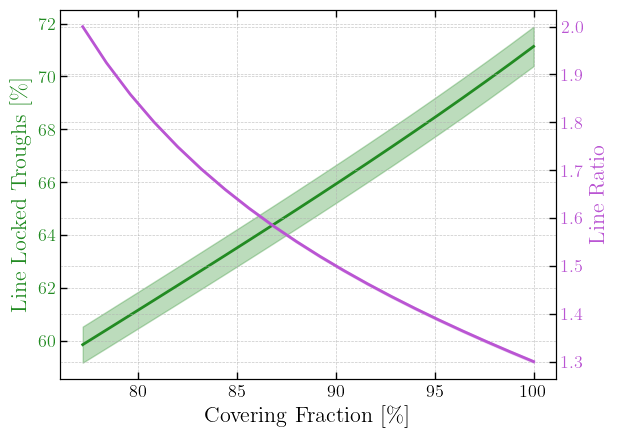

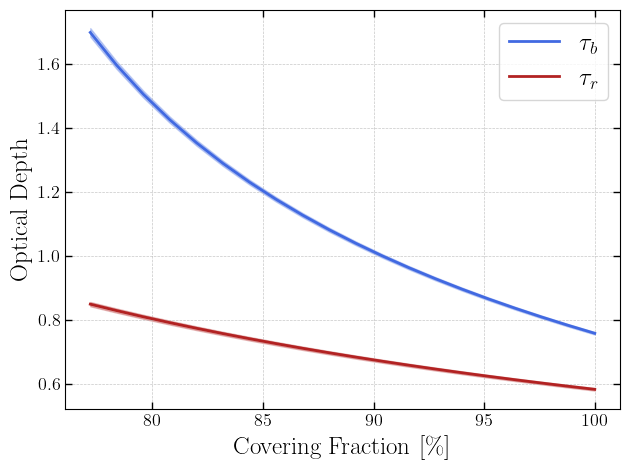

In [21]:
cover_factors = np.linspace(0.772, 1.00, 20)  # Cover fraction

initial_fraction_guesses = np.linspace(0.55, 0.7, 20)
initial_B_guesses = np.linspace(0.2, 0.46, 20)
initial_R_guesses = np.linspace(0.48, 0.58, 20)

fractions1 = []
line_ratios1 = []
tau_red_1 = []
tau_blue_1 = []
fractions2 = []
line_ratios2 = []
tau_red_2 = []
tau_blue_2 = []
fractions3 = []
line_ratios3 = []
tau_red_3 = []
tau_blue_3 = []
for i, cover_factor in enumerate(cover_factors):
    C = cover_factor
    # Solve the system of equations for lower bound of contamination fraction
    xc = 0.00
    initial_guess = [initial_fraction_guesses[i], initial_B_guesses[i], initial_R_guesses[i]]
    solution = fsolve(system_of_equations, initial_guess)
    fractions1.append(solution[0])
    line_ratios1.append(-np.log(solution[1])/(-np.log(solution[2])))
    tau_red_1.append(-np.log(solution[2]))
    tau_blue_1.append(-np.log(solution[1]))
     # Solve the system of equations for the most probable contamination fraction
    xc=0.005
    solution = fsolve(system_of_equations, initial_guess)
    fractions2.append(solution[0])
    line_ratios2.append(-np.log(solution[1])/(-np.log(solution[2])))
    tau_red_2.append(-np.log(solution[2]))
    tau_blue_2.append(-np.log(solution[1]))
     # Solve the system of equations for upper bound of contamination fraction
    xc = 0.01
    solution = fsolve(system_of_equations, initial_guess)
    fractions3.append(solution[0])
    line_ratios3.append(-np.log(solution[1])/(-np.log(solution[2])))
    tau_red_3.append(-np.log(solution[2]))
    tau_blue_3.append(-np.log(solution[1]))

color1 = 'forestgreen'
color2 = 'mediumorchid'
fig, ax1 = plt.subplots()
# Left Y-axis
ax1.fill_between(cover_factors * 100, [x * 100 for x in fractions1], [x * 100 for x in fractions3], color=color1, alpha=0.3)
ax1.plot(cover_factors * 100, [x * 100 for x in fractions2], color=color1, label='Line Locked Troughs', lw=2)
ax1.set_xlabel(r'Covering Fraction [\%]', fontsize=labelsize)
ax1.set_ylabel(r'Line Locked Troughs [\%]', color=color1, fontsize=labelsize)
# General tick settings for ax1
ax1.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize, labelcolor=color1)
# Explicitly set bottom x-axis ticks to black
ax1.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# Right Y-axis
ax2 = ax1.twinx()
ax2.fill_between(cover_factors * 100, line_ratios1, line_ratios3, color=color2, alpha=0.3)
ax2.plot(cover_factors * 100, line_ratios2, color=color2, label='Line Ratios', lw=2)
ax2.set_ylabel('Line Ratio', color=color2, fontsize=labelsize)
ax2.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize, labelcolor=color2)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.savefig("./Results/Figures/Line_Locking_Fraction.png", bbox_inches="tight", dpi=300)
plt.show()


plt.fill_between(cover_factors * 100, tau_blue_1, tau_blue_3, color='royalblue', alpha=0.3)
plt.plot(cover_factors * 100, tau_blue_2, color='royalblue', label=r'$\tau_b$', lw=2)
plt.fill_between(cover_factors * 100, tau_red_1, tau_red_3, color='firebrick', alpha=0.3)
plt.plot(cover_factors * 100, tau_red_2, color='firebrick', label=r'$\tau_r$', lw=2)
plt.xlabel(r'Covering Fraction [\%]', fontsize=labelsize+2)
plt.ylabel(r'Optical Depth', fontsize=labelsize+2)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.legend(fontsize=labelsize+2)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig("./Results/Figures/Optical_Depths.png", bbox_inches="tight", dpi=300)
plt.show()

## Calculate the Column Density

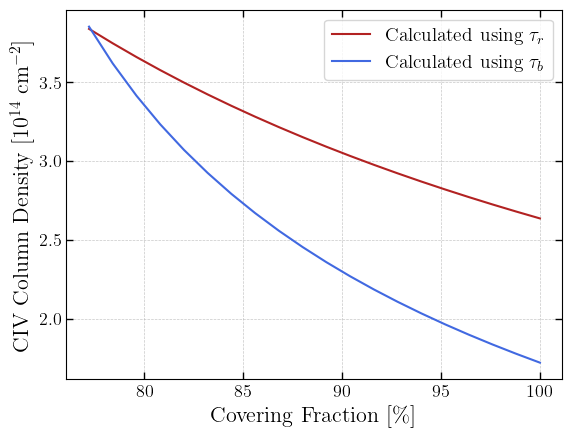

In [23]:
red_Density = []
for tau in tau_red_2:
    red_Density.append(LineLocking.column_density_from_tau(tau, 1551).value)

blue_Density = []
for tau in tau_blue_2:
    blue_Density.append(LineLocking.column_density_from_tau(tau, 1548).value)

plt.plot(cover_factors*100, np.array(red_Density)/10**(14), c='firebrick', label=r'Calculated using $\tau_r$')
plt.plot(cover_factors*100, np.array(blue_Density)/10**(14), c='royalblue', label=r'Calculated using $\tau_b$')
plt.xlabel(r'Covering Fraction [\%]', fontsize=labelsize)
plt.ylabel(r'CIV Column Density [$10^{14}$ cm$^{-2}$]', fontsize=labelsize)
# General tick settings for ax1
plt.tick_params(axis='y', direction='in', top=True, right=True, length=5, width=1,
                labelsize=ticksize)
# Explicitly set bottom x-axis ticks to black
plt.tick_params(axis='x', direction='in', top=True, length=5, width=1,
                labelsize=ticksize, labelcolor='black', color='black')
plt.legend(fontsize=labelsize-2)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.savefig("./Results/Figures/CIV_Density.png", bbox_inches="tight", dpi=300)
plt.show()

-0.09254083012111457


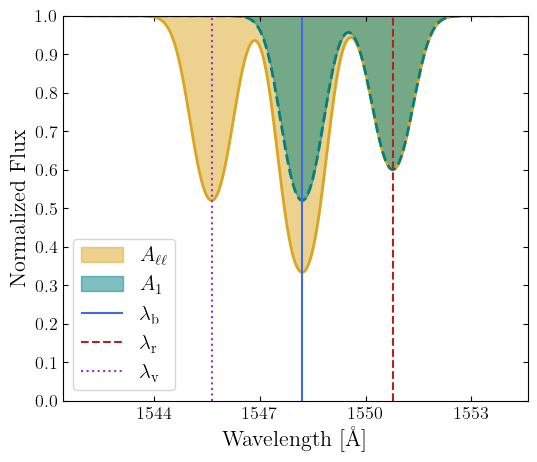

In [ ]:
from scipy.integrate import simpson  # or trapezoid

Delta = 0.5     # Width of the absorption lines
C = 0.9         # Cover fraction
tb=-np.log(solution[1])
tr=-np.log(solution[2])

lb = 1548.20
lr = 1550.77
lv = 1545.63

l = np.linspace(1542, 1554, 10000)  # high-res grid covering your lines


def I1_func(l, tb, tr):
    return 1-C+C*np.exp(-tb*np.exp(-(l-lb)**2/(2*Delta**2))-tr*np.exp(-(l-lr)**2/(2*Delta**2)))
def I2_func(l, tb, tr):
    return 1-C+C*np.exp(-tb*np.exp(-(l-lb)**2/(2*Delta**2))-tr*np.exp(-(l-lr)**2/(2*Delta**2))-tb*np.exp(-(l-lv)**2/(2*Delta**2))-tr*np.exp(-(l-lb)**2/(2*Delta**2)))

I1 = I1_func(l, tb, tr)
I2 = I2_func(l, tb, tr)
area_I1 = simpson(I1, l)*-1
area_I2 = simpson(I2, l)*-1
print((area_I2-area_I1)/area_I1)

#lightseagreen,hotpink
labelsize=16
ticksize = 13
fig, ax = plt.subplots(1,1, figsize=(6, 5), sharey=True)
ax.plot(l, I2_func(l, tb, tr), c='goldenrod', lw=2)
ax.fill_between(l, I2_func(l, tb, tr), np.ones(len(l)), alpha=0.5, color='goldenrod', label=r'$A_{\ell\ell}$')
ax.plot(l, I1_func(l, tb, tr), c='teal', linestyle='--', lw=2)
ax.fill_between(l, I1_func(l, tb, tr), np.ones(len(l)), alpha=0.5, color='teal', label=r'$A_1$')
ax.set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
ax.set_ylabel('Normalized Flux', fontsize=labelsize)
ax.set_ylim(0.0, 1)
ax.set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
ax.set_xticks([1541,1544,1547,1550,1553,1556])
ax.vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$')
ax.vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
ax.vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$')
ax.tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
plt.legend(fontsize=ticksize+2)
plt.savefig("./Results/Figures/maskingFraction.png", bbox_inches="tight", dpi=300)
plt.show()

## Compare Width Binning

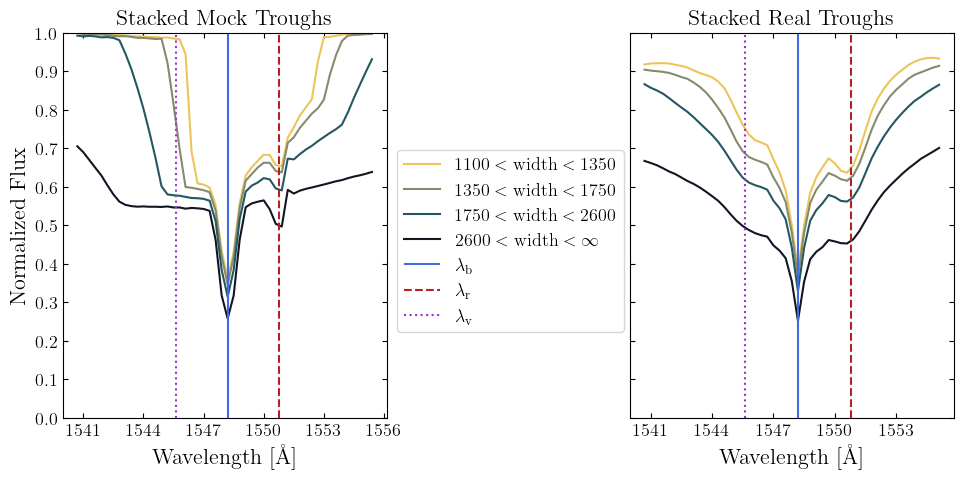

In [ ]:
data1 = np.load('/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/Width_Stacks/stacked1.npz')
MockWL1 = data1['Mockwavelengths']
MockStack1 = data1['Mockstacks']
RealWL1 = data1['Realwavelengths']
RealStack1 = data1['Realstacks']
data2 = np.load('/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/Width_Stacks/stacked2.npz')
MockWL2 = data2['Mockwavelengths']
MockStack2 = data2['Mockstacks']
RealWL2 = data2['Realwavelengths']
RealStack2 = data2['Realstacks']
data3 = np.load('/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/Width_Stacks/stacked3.npz')
MockWL3 = data3['Mockwavelengths']
MockStack3 = data3['Mockstacks']
RealWL3 = data3['Realwavelengths']
RealStack3 = data3['Realstacks']
data4 = np.load('/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/Width_Stacks/stacked4.npz')
MockWL4 = data4['Mockwavelengths']
MockStack4 = data4['Mockstacks']
RealWL4 = data4['Realwavelengths']
RealStack4 = data4['Realstacks']

cmap = cm.eclipse
c1 = cmap.colors[225]
c2 = cmap.colors[160]
c3 = cmap.colors[95]
c4 = cmap.colors[30]


# Plot the Stacks
labelsize=16
ticksize = 13
fig, axes = plt.subplots(1,2, figsize=(11.5, 5), sharey=True)
axes[0].plot(MockWL1, MockStack1, c=c1)
axes[0].plot(MockWL2, MockStack2, c=c2)
axes[0].plot(MockWL3, MockStack3, c=c3)
axes[0].plot(MockWL4, MockStack4, c=c4)
axes[0].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[0].set_ylabel('Normalized Flux', fontsize=labelsize)
axes[0].set_title('Stacked Mock Troughs', fontsize=labelsize)
axes[0].set_ylim(0.0, 1)
axes[0].set_yticks([0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9, 1.0])
axes[0].set_xticks([1541,1544,1547,1550,1553,1556])
axes[0].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-')
axes[0].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--')
axes[0].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':')
axes[0].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)

axes[1].plot(RealWL1, RealStack1, c=c1, label=r'$1100<\mathrm{width}<1350$')
axes[1].plot(RealWL2, RealStack2, c=c2, label=r'$1350<\mathrm{width}<1750$')
axes[1].plot(RealWL3, RealStack3, c=c3, label=r'$1750<\mathrm{width}<2600$')
axes[1].plot(RealWL4, RealStack4, c=c4, label=r'$2600<\mathrm{width}<\infty$')
axes[1].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[1].set_title('Stacked Real Troughs', fontsize=labelsize)
axes[1].set_ylim(0.0, 1)
axes[1].set_xticks([1541,1544,1547,1550,1553,1556])
axes[1].vlines(x=1548.2, ymin=0, ymax=1, color='royalblue', linestyle='-', label=r'$\lambda_{\mathrm{b}}$')
axes[1].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick', linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
axes[1].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':', label=r'$\lambda_{\mathrm{v}}$')
axes[1].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)
axes[1].legend(fontsize=ticksize, loc='lower right', bbox_to_anchor=(0.01, 0.2))

plt.subplots_adjust(wspace=0.75)
plt.savefig("./Results/Figures/Width_Stacks.png", bbox_inches="tight", dpi=300)
plt.show()

Creating a Sample of 4711 Mock Spectra...


  0%|          | 0/4711 [00:00<?, ?it/s]

Building up Mock Statistics...


  0%|          | 0/4711 [00:00<?, ?it/s]

Finished! 0 troughs rejected.
Creating a Sample of 5084 Mock Spectra...


...

Finished! 0 troughs rejected.
Creating a Sample of 4761 Mock Spectra...


  0%|          | 0/4761 [00:00<?, ?it/s]

Building up Mock Statistics...


  0%|          | 0/4761 [00:00<?, ?it/s]

Finished! 0 troughs rejected.


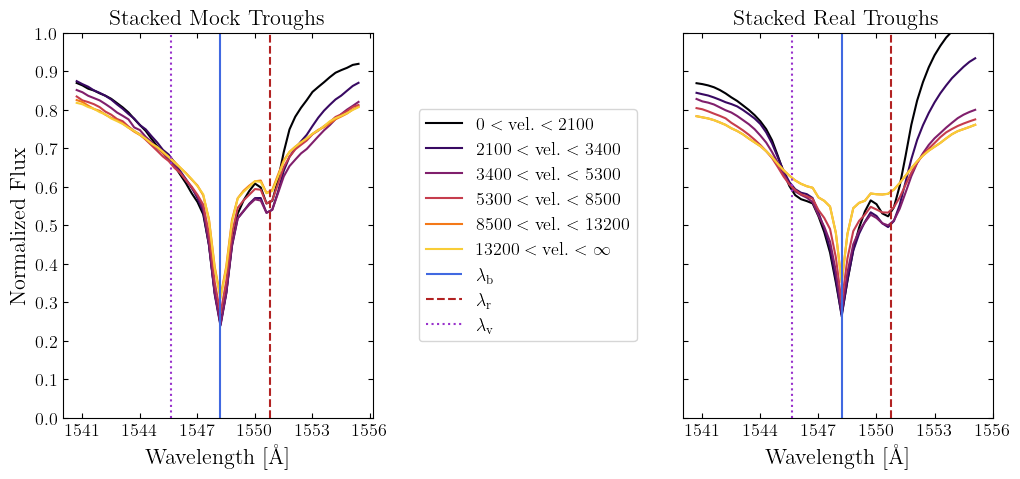

In [ ]:
def mock_and_real_stack(save_file):
    # Step 1) Read in data from save file to consruct the KDE
    data = pd.read_csv(f"/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/LineLocking_Stats_{save_file}.csv")
    values = np.vstack([data['Blue Depths'], data['Red Depths'], data['Noises'], data['Trough Depths'], data['Trough Widths'], data['Triplet Depths'], data['Trough Center']])
    master_KDE = gaussian_kde(values, bw_method=1/8)

    # Step 2) USe master_KDE to construct an equivelent number of mock spectra
    Mock_Trough_Table = pd.DataFrame(columns = ["Wavelengths", "Flux", "Trough Width", "Noise", 'Trough Center'])
    # Create and store thousands of mock spectra 
    print(f'Creating a Sample of {data.shape[0]} Mock Spectra...')
    for k in tqdm(range(data.shape[0])):
        wavelengths, Flux, params = LineLocking.generate_spectra(wavelength_range=(1548.2-60*0.3, 1548.2+60*0.3), KDE=master_KDE, return_params=True, triplet=use_mock_triplet)
        Mock_Trough_Table.loc[ len(Mock_Trough_Table) ] = [wavelengths, Flux, params['Trough Width'][0], params['Noise'][0], params['Trough Center'][0]]

    # Step 3) Extract stacking spectra from table of mock spectra
    print(f'Building up Mock Statistics...')
    mock_stats, mock_stacking_spectra = LineLocking.get_mock_spectra_stats(Mock_Trough_Table)
    print(f'Finished! {mock_stats['Rejection Counter'][0]} troughs rejected.')

    # Step 4) Stack the Mock Spectra
    stacked_mocks, stacked_mocks_error = nanweighted_mean_std(np.vstack(mock_stacking_spectra), mock_stats["Weights"], axis=0)
    stacking_wavelengths_mocks = np.arange(1548.2-25*0.3, 1548.2+25*0.3, 0.3)

    # Step 5) Stack the Real Spectra
    stacking_spectra_data = np.loadtxt(f'/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cuts/stacking_spectra_{save_file}.csv', delimiter=',')
    stacked_spectra, stacked_spectra_error = nanweighted_mean_std(np.vstack(stacking_spectra_data), data["Weights"], axis=0)
    stacking_wavelengths = np.arange(900.2, 1599.8, 0.3)
    CIV_wlMin = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[0]))
    CIV_wlMax = np.argmin(np.abs(stacking_wavelengths-stacking_wavelengths_mocks[-1]))

    return [stacked_mocks, stacked_spectra[CIV_wlMin:CIV_wlMax]], [stacking_wavelengths_mocks, stacking_wavelengths[CIV_wlMin:CIV_wlMax]]




stacks1, wl_stacking = mock_and_real_stack('Final_N_Vel1')
stacks2, _           = mock_and_real_stack('Final_N_Vel2')
stacks3, _           = mock_and_real_stack('Final_N_Vel3')
stacks4, _           = mock_and_real_stack('Final_N_Vel4')
stacks5, _           = mock_and_real_stack('Final_N_Vel5')
stacks6, _           = mock_and_real_stack('Final_N_Vel6')



cmap = plt.cm.inferno
c1 = cmap(0.0)
c2 = cmap(0.176)
c3 = cmap(0.352)
c4 = cmap(0.528)
c5 = cmap(0.704)
c6 = cmap(0.88)

# Plot the Stacks
labelsize = 16
ticksize  = 13
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(wl_stacking[0], stacks1[0], c=c1)
axes[0].plot(wl_stacking[0], stacks2[0], c=c2)
axes[0].plot(wl_stacking[0], stacks3[0], c=c3)
axes[0].plot(wl_stacking[0], stacks4[0], c=c4)
axes[0].plot(wl_stacking[0], stacks5[0], c=c5)
axes[0].plot(wl_stacking[0], stacks6[0], c=c6)
axes[0].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[0].set_ylabel('Normalized Flux', fontsize=labelsize)
axes[0].set_title('Stacked Mock Troughs', fontsize=labelsize)
axes[0].set_ylim(0.0, 1)
axes[0].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
axes[0].set_xticks([1541, 1544, 1547, 1550, 1553, 1556])
axes[0].vlines(x=1548.2,  ymin=0, ymax=1, color='royalblue',  linestyle='-')
axes[0].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick',  linestyle='--')
axes[0].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':')
axes[0].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)

axes[1].plot(wl_stacking[1], stacks1[1], c=c1, label=r'$0<\mathrm{vel.}<2100$')
axes[1].plot(wl_stacking[1], stacks2[1], c=c2, label=r'$2100<\mathrm{vel.}<3400$')
axes[1].plot(wl_stacking[1], stacks3[1], c=c3, label=r'$3400<\mathrm{vel.}<5300$')
axes[1].plot(wl_stacking[1], stacks4[1], c=c4, label=r'$5300<\mathrm{vel.}<8500$')
axes[1].plot(wl_stacking[1], stacks5[1], c=c5, label=r'$8500<\mathrm{vel.}<13200$')
axes[1].plot(wl_stacking[1], stacks6[1], c=c6, label=r'$13200<\mathrm{vel.}<\infty$')
axes[1].vlines(x=1548.2,  ymin=0, ymax=1, color='royalblue',  linestyle='-',  label=r'$\lambda_{\mathrm{b}}$')
axes[1].vlines(x=1550.77, ymin=0, ymax=1, color='firebrick',  linestyle='--', label=r'$\lambda_{\mathrm{r}}$')
axes[1].vlines(x=1545.63, ymin=0, ymax=1, color='darkorchid', linestyle=':',  label=r'$\lambda_{\mathrm{v}}$')
axes[1].set_xlabel(r'Wavelength [\AA]', fontsize=labelsize)
axes[1].set_title('Stacked Real Troughs', fontsize=labelsize)
axes[1].set_ylim(0.0, 1)
axes[1].set_xticks([1541, 1544, 1547, 1550, 1553, 1556])
axes[1].tick_params(axis='both', labelsize=ticksize, direction='in', top=True, right=True)

plt.subplots_adjust(wspace=1.0)

# Place legend exactly centred in the gap between the two panels
fig.canvas.draw()  # finalise layout so get_position() is accurate
pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
gap_centre_x = (pos0.x1 + pos1.x0) / 2
gap_centre_y = (pos0.y0 + pos0.y1) / 2

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='center',
           bbox_to_anchor=(gap_centre_x, gap_centre_y),
           fontsize=ticksize,
           frameon=True)

plt.savefig("./Results/Figures/Velocity_Stacks.png", bbox_inches="tight", dpi=300)
plt.show()